# Fine-Tuned Person Re-Identification on PRW

End-to-end person search on the PRW dataset using only pretrained models — no task-specific training.

**Task**: given a query crop of a person, find that person across 6,112 whole-scene gallery frames.

**Pipeline**: detect all persons in gallery frames → extract visual features (DINOv2) → optionally enrich with text features (Gemma4 captions + CLIP) → cosine-similarity ranking.

| Config | Detector | Visual | Captions | Purpose |
|--------|----------|--------|----------|---------|
| A | YOLOv12 | DINOv2 | — | Visual-only baseline |
| B | YOLOv12 | DINOv2 | Gemma4 + CLIP | Add text enrichment |
| C | RF-DETR | DINOv2 | Gemma4 + CLIP | Swap detector |

In [1]:
import os
import re
import sys
import json
import warnings
import zipfile
from pathlib import Path
from typing import Optional

import numpy as np
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import random
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as T

from ultralytics import YOLO
from rfdetr import RFDETRBase
from transformers import AutoImageProcessor, AutoModel
from pytorch_metric_learning import losses, miners
from pytorch_metric_learning.samplers import MPerClassSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

sys.path.insert(0, str(Path('.').resolve()))
from utils.eval_function import eval_search_prw

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

/home/leonardo/github/ds-dashboard/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# dataset paths and urls
DATASET_ROOT = 'dataset'
ZIP="prw-person-re-identification-in-the-wild.zip"
URL="https://www.kaggle.com/api/v1/datasets/download/edoardomerli/prw-person-re-identification-in-the-wild"
TRAIN_CROPS_DIR = Path(f'{DATASET_ROOT}/query_box_train') # training crops for re-id finetuning

# cache directories; useful to store detections and embeddings without rerun
CACHE_DIR = Path(f'finetune_cache')
CACHE_DIR.mkdir(exist_ok=True)

# configurations, easy to define and extend multiple experiments
DETECTOR_CONFIGS = {
    "yolo12": {"detector": "yolo12", "threshold": 0.3},
    "rfdetr": {"detector": "rfdetr", "threshold": 0.5},
}

REID_CONFIGS = {
    "arcface": {"encoder": "dinov3",  "loss": "arcface", "embed_dim" : 1024},
    "triplet": {"encoder": "dinov3",  "loss": "triplet", "embed_dim" : 1024},
    "ntxent":  {"encoder": "dinov3",  "loss": "ntxent",  "embed_dim" : 1024},
}

PERSONSEARCH_CONFIGS = {
    "A": {**DETECTOR_CONFIGS["yolo12"], **REID_CONFIGS["arcface"]},
    "B": {**DETECTOR_CONFIGS["yolo12"], **REID_CONFIGS["triplet"]},
    "C": {**DETECTOR_CONFIGS["yolo12"], **REID_CONFIGS["ntxent"]},
    "D": {**DETECTOR_CONFIGS["rfdetr"], **REID_CONFIGS["arcface"]},
    "E": {**DETECTOR_CONFIGS["rfdetr"], **REID_CONFIGS["triplet"]},
    "F": {**DETECTOR_CONFIGS["rfdetr"], **REID_CONFIGS["ntxent"]},
}    

### Downloading and extracting the dataset

In [3]:
DATASET_ROOT="dataset"
ZIP="prw-person-re-identification-in-the-wild.zip"
URL="https://www.kaggle.com/api/v1/datasets/download/edoardomerli/prw-person-re-identification-in-the-wild"

# check if dataset exists already
if Path(DATASET_ROOT).exists() and any(Path(DATASET_ROOT).iterdir()):
    print(f"{DATASET_ROOT} already exists and is non-empty - skipping download.")

elif Path(ZIP).exists():
    print(f"'{ZIP}' already downloaded - skipping download.")

# otw download
else:
    print(f"Downloading dataset to ./{ZIP} ...")
    !curl -L -o {ZIP} {URL}
    print("Download complete.")

dataset already exists and is non-empty - skipping download.


In [4]:
# extract the downloaded zip. skip extraction if exists already
if os.path.isdir(DATASET_ROOT) and os.listdir(DATASET_ROOT):
    print(f"'{DATASET_ROOT}/' already exists and is non-empty - skipping extraction.")
else:
    os.makedirs(DATASET_ROOT, exist_ok=True)
    print(f"Extracting {ZIP} into {DATASET_ROOT}/ ...")
    with zipfile.ZipFile(ZIP, "r") as zip_ref:
        zip_ref.extractall(DATASET_ROOT)
    print("Extraction complete.")

'dataset/' already exists and is non-empty - skipping extraction.


### building training query boxes for re-id finetuning

In [6]:
# %%bash
# # generates training query boxes by calling generate_query_train.py
# uv run generate_query_train.py

# Detection!

## 1. Dataset (must change the description)

Two splits:
- **Gallery** (6,112 test frames): whole-scene images; we detect persons in these.
- **Query** (2,057 images): pre-cropped person images from `dataset/query_box/`.

Annotation boxes are stored as `[x, y, w, h]` in the raw `.mat` files and `query_info.txt`; we convert to `[x1, y1, x2, y2]` throughout.

The query `img_name` is set to the **source frame** name (e.g. `c1s3_016471.jpg`) — this is required by `eval_search_prw` so it can exclude that frame from the gallery during evaluation. `get_image_path` constructs the actual crop path (`{pid}_{frame_base}.jpg` in `query_box/`).

In [7]:
class PRWDataset: # this is the detector dataset
    """
    Wraps either the gallery or query split of PRW.

    annotations : list[dict]
        img_name  (str)          — bare filename; for queries this is the SOURCE frame
                                   name used by eval_search_prw for gallery exclusion
        cam_id    (int)          — camera 1–6
        pids      (ndarray|int)  — [N] int32 array (gallery) or scalar int (query)
        boxes     (ndarray)      — [N,4] float32 in x1,y1,x2,y2
    img_prefix : str — directory containing the images
    is_query   : bool — when True, get_image_path reconstructs the crop filename
    """

    def __init__(self, annotations: list, img_prefix: str, is_query: bool = False, split: str = 'test') -> None:
        self.annotations = annotations
        self.img_prefix  = img_prefix
        self.is_query    = is_query
        self.split       = split

    def __len__(self) -> int:
        return len(self.annotations)

    def get_image_path(self, idx: int) -> str:
        ann = self.annotations[idx]
        if self.is_query:
            # img_name = 'c1s3_016471.jpg'  →  crop = '479_c1s3_016471.jpg'
            frame_base = ann['img_name'].rsplit('.', 1)[0]
            id_frame_prefix = f"{(3 - len(str(ann['pids']))) * '0'}{ann['pids']}"
            return os.path.join(self.img_prefix, f"{id_frame_prefix}_{frame_base}.jpg")
        return os.path.join(self.img_prefix, ann['img_name'])

In [ ]:
def _cam_id_from_name(name: str) -> int:
    m = re.search(r'c(\d+)', name)
    if m is None:
        raise ValueError(f'Cannot parse camera ID from: {name}')
    return int(m.group(1))


def _xywh_to_xyxy(x: float, y: float, w: float, h: float) -> list:
    return [x, y, x + w, y + h]


def build_gallery_dataset(dataset_root: str = 'dataset', split: str = 'test') -> PRWDataset:
    """
    Build gallery PRWDataset from the split frames.
    Reads frame_{split}.mat and per-frame .mat annotation files.
    """
    root       = Path(dataset_root)
    split_str = split
    split_arr   = loadmat(str(root / f'frame_{split_str}.mat'))[f'img_index_{split_str}'].ravel()
    split_names = [x.item() for x in split_arr]   # names wo extension

    ann_dir     = root / 'annotations'
    annotations = []
    for name in tqdm(split_names, desc='Loading gallery annotations'):
        mat     = loadmat(str(ann_dir / f'{name}.jpg.mat'))
        box_new = mat.get("box_new", # [N, 5]: pid, x, y, w, h
                          mat.get("anno_file",
                            mat.get("anno_previous", None))) # argg there exist different names

        pids    = box_new[:, 0].astype(np.int32)
        boxes = np.array(
            [np.array(_xywh_to_xyxy(*box[1:]), dtype=np.float32) for box in box_new]
        ).astype(np.float32)

        annotations.append({
            'img_name': f'{name}.jpg',
            'cam_id':   _cam_id_from_name(name),
            'pids':     pids,
            'boxes':    boxes,
        })

    return PRWDataset(annotations, str((root / 'frames').resolve()), is_query=False, split=split)


def build_query_dataset(dataset_root: str = 'dataset', split: str = 'test') -> PRWDataset:
    """
    Build query PRWDataset from query_info.txt (2,057 queries).
    Line format: pid x y w h frame_name
    """
    root        = Path(dataset_root)
    annotations = []
    split_str = "_train" if split == "train" else ""
    with open(root / f'query_info{split_str}.txt') as f:
        for line in f:
            parts      = line.strip().split()
            pid        = int(parts[0])
            x, y, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            frame_name = parts[5]
            annotations.append({
                'img_name': f'{frame_name}.jpg',   # source frame name — for eval exclusion
                'cam_id':   _cam_id_from_name(frame_name),
                'pids':     pid,                   # scalar int
                'boxes':    np.array([_xywh_to_xyxy(x, y, w, h)], dtype=np.float32),
            })

            if split == "train" and len(annotations) == 3000:
                break # 3000 queries is enough to evaluate detector's recall_rate

    return PRWDataset(annotations, str((root / f'query_box{split_str}').resolve()), is_query=True, split=split)

In [ ]:
query_dataset   = build_query_dataset(DATASET_ROOT, split="train")   # needed for evaluation of recall_rate
gallery_dataset = build_gallery_dataset(DATASET_ROOT, split="train") # needed for detection

print(f'Gallery frames : {len(gallery_dataset)}')    # test: 6112
print(f'Query images   : {len(query_dataset)}')      # test: 2057

g0 = gallery_dataset.annotations[0]
q0 = query_dataset.annotations[0]
print(f'\nGallery[0]: {g0["img_name"]}, cam={g0["cam_id"]}, '
      f'n_persons={len(g0["pids"])}, boxes.shape={g0["boxes"].shape}')
print(f'Query[0]  : {q0["img_name"]}, cam={q0["cam_id"]}, '
      f'pid={q0["pids"]}, box={q0["boxes"]}')
print(f'Query[0] crop path: {query_dataset.get_image_path(0)}')

Loading gallery annotations:   0%|          | 0/5704 [00:00<?, ?it/s]

Loading gallery annotations: 100%|██████████| 5704/5704 [00:00<00:00, 10364.77it/s]

Gallery frames : 5704
Query images   : 3000

Gallery[0]: c1s1_000151.jpg, cam=1, n_persons=2, boxes.shape=(2, 4)
Query[0]  : c1s1_001051.jpg, cam=1, pid=1, box=[[     1222.9       433.2      1374.5       748.1]]
Query[0] crop path: /home/leonardo/github/ds-dashboard/dataset/query_box_train/001_c1s1_001051.jpg


## 2. Detectors backbones

All detectors share the same interface: `detect_frame(path) → ndarray[n_det, 5]` where columns are `[x1, y1, x2, y2, score]`.

Detection uses a **loose confidence threshold (0.3)** so borderline detections are preserved in the cache. `eval_search_prw` applies `DET_THRESH=0.5` as a second filter — this lets us sweep `DET_THRESH` without re-running the expensive detection step.

In [ ]:
class BaseDetector:
    def detect_frame(self, img_path: str) -> np.ndarray:
        """Return [n_det, 5] float32 (x1,y1,x2,y2,score), or [0,5] if none found."""
        raise NotImplementedError

    def detect_batch(self, img_paths: list, desc: str = 'Detecting') -> list:
        return [self.detect_frame(p) for p in tqdm(img_paths, desc=desc, unit='frame')]


class YOLODetector(BaseDetector):
    """YOLOv12 person detector via ultralytics"""

    _PERSON_CLS = 0 # yolo class index for 'person'

    def __init__(self, model_name: str = 'yolo12s.pt', conf_thresh: float = 0.3,
                 device: str = DEVICE) -> None:
        self.model       = YOLO(model_name)
        self.conf_thresh = conf_thresh
        self.device      = device

    def detect_frame(self, img_path: str) -> np.ndarray:
        results = self.model(
            img_path,
            classes=[self._PERSON_CLS],
            conf=self.conf_thresh,
            verbose=False,
            device=self.device,
        )
        r = results[0]
        if len(r.boxes) == 0:
            return np.zeros((0, 5), dtype=np.float32)
        boxes  = r.boxes.xyxy.cpu().numpy()           # [N, 4]
        scores = r.boxes.conf.cpu().numpy()[:, None]  # [N, 1]
        return np.concatenate([boxes, scores], axis=1).astype(np.float32)
    

class RFDETRDetector(BaseDetector):
    """RF-DETR person detector"""

    _PERSON_CLS = 1 # rfdetr class index for 'person' 

    def __init__(self, conf_thresh: float = 0.5) -> None:
        self.model       = RFDETRBase()
        self.model.optimize_for_inference()
        self.conf_thresh = conf_thresh

    def detect_frame(self, img_path: str) -> np.ndarray:
        img  = Image.open(img_path).convert('RGB')
        dets = self.model.predict(img, threshold=self.conf_thresh)
        mask = dets.class_id == self._PERSON_CLS
        if mask.sum() == 0:
            return np.zeros((0, 5), dtype=np.float32)
        boxes  = dets.xyxy[mask]
        scores = dets.confidence[mask][:, None]
        return np.concatenate([boxes, scores], axis=1).astype(np.float32)


def build_detector(config: dict) -> BaseDetector:
    if config['detector'] == 'yolo12':
        return YOLODetector(model_name='yolo12s.pt', device=DEVICE)
    elif config['detector'] == 'rfdetr':
        return RFDETRDetector()
    raise ValueError(f"Unknown detector: {config['detector']}")

## Gallery Detection

1. **Detection** — run detector on all 6,112 frames → `[n_det, 5]` per frame

In [ ]:
def _crop_persons(frame: Image.Image, dets: np.ndarray) -> list:
    """Crop detected bounding boxes from a PIL frame, clipping to image bounds."""
    W, H  = frame.size
    crops = []
    for x1, y1, x2, y2, _ in dets:
        x1c, y1c = max(0, int(x1)), max(0, int(y1))
        x2c, y2c = min(W, int(x2)), min(H, int(y2))
        if x2c > x1c and y2c > y1c:
            crops.append(frame.crop((x1c, y1c, x2c, y2c)))
        else:
            crops.append(Image.new('RGB', (64, 128)))   # degenerate bbox fallback
    return crops


def run_gallery_detection(gallery_dataset: PRWDataset, detector: BaseDetector,
                          cache_path: Path, force: bool = False) -> list:
    """
    Detect persons in all gallery frames. Returns list of [n_det, 5] float32 arrays.
    Caches results as a numpy object array; loads from cache if available.
    """
    if cache_path.exists() and not force:
        print(f'Loading detections from cache: {cache_path}')
        return list(np.load(str(cache_path), allow_pickle=True))

    img_paths    = [gallery_dataset.get_image_path(i) for i in range(len(gallery_dataset))]
    gallery_dets = detector.detect_batch(img_paths, desc='Detecting gallery')

    arr = np.empty(len(gallery_dets), dtype=object)
    for i, d in enumerate(gallery_dets):
        arr[i] = d if d.shape[0] > 0 else np.zeros((0, 5), dtype=np.float32)
    np.save(str(cache_path), arr)
    print(f'Saved detections: {cache_path}')
    return list(arr)

In [ ]:
EVALUATE_DETECTORS = False

for RUN_CONFIG, cfg in DETECTOR_CONFIGS.items():
    # cache paths to avoid reruns
    DETS_CACHE = CACHE_DIR / f'gallery_dets_train_{RUN_CONFIG}.npy'
    DET_THRESH = cfg["threshold"]
    # build detector from config dict
    detector = build_detector(cfg)
    gallery_dets = run_gallery_detection(gallery_dataset, detector, DETS_CACHE)

    if EVALUATE_DETECTORS:
        # evaluate detectors with recall_rate available in the eval_function
        recall_rate = eval_search_prw(
            gallery_dataset=gallery_dataset,
            query_dataset=query_dataset,
            gallery_dets=gallery_dets,
            gallery_feats=None,
            query_box_feats=None,
            det_thresh=DET_THRESH,
            validate_detector_only=True
        )

        out = {"recall_rate": recall_rate}
        
        # save result to json
        results_path = CACHE_DIR / f'recall_rate_{RUN_CONFIG}.json'
        with open(results_path, 'w') as f:
            json.dump(out, f, indent=2)
        print(f'\nResults saved: {results_path}')

Loading detections from cache: finetune_cache/gallery_dets_train_yolo12.npy
[2026-05-19 08:44:09] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-19 08:44:10] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Loading detections from cache: finetune_cache/gallery_dets_train_rfdetr.npy


In [11]:
def plot_crop_samples(n_samples: int = 12, n_cols: int = 4) -> None:
    candidates = [
        (fi, di)
        for fi, dets in enumerate(gallery_dets)
        for di in range(len(dets))
    ]
    k = min(n_samples, len(candidates))
    sampled = random.sample(candidates, k)

    n_rows = (k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()

    for ax, (fi, di) in zip(axes, sampled):
        ann = gallery_dataset.annotations[fi]
        frame = Image.open(os.path.join(gallery_dataset.img_prefix, ann['img_name']))
        x1, y1, x2, y2 = (int(v) for v in gallery_dets[fi][di][:4])
        crop = frame.crop((max(0, x1), max(0, y1), x2, y2))
        ax.imshow(crop)
        ax.axis('off')
        title = ann['img_name']
        ax.set_title(title, fontsize=7)

    for ax in axes[k:]:
        ax.axis('off')

    suptitle = 'Crop samples'
    plt.suptitle(suptitle, fontsize=10)
    plt.tight_layout()
    plt.show()

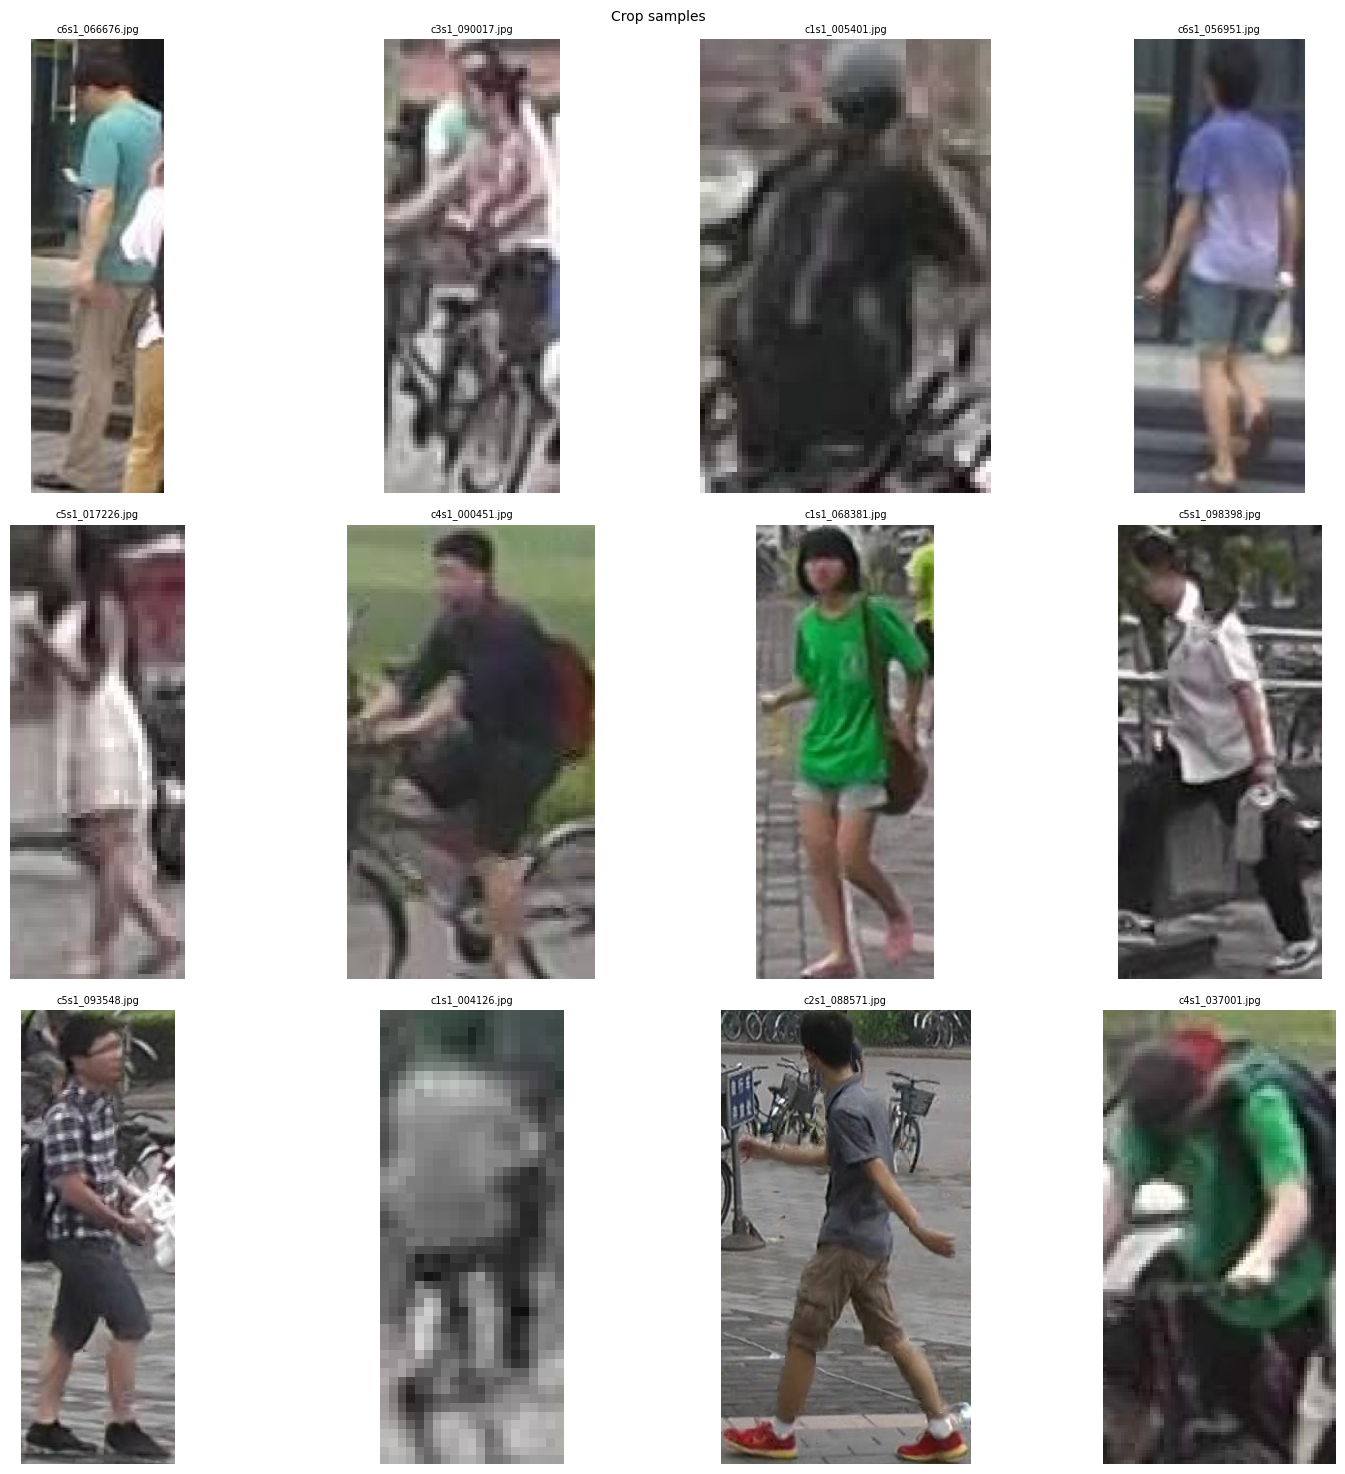

In [14]:
plot_crop_samples()

# Re-Identification

## Dataset

In [12]:
def _parse_pid_from_filename(name: str) -> int:
    # query boxes are 'NNN_queryboxname.jpg'
    return int(name.split('_', 1)[0])


class PRWQueryBoxDataset(Dataset): # this is the re-id backbone dataset. this reads directly from query box train.
    """
    Person crops for fine-tuning. Returns (PIL_image, label) tuples; transforms
    + processor are applied in the collate_fn so we can vary them between
    train and eval splits.

    `id2label` maps raw PRW pid → contiguous [0, num_ids) label
    (required by ArcFace and friends).
    """

    def __init__(self, crops_dir: Path = TRAIN_CROPS_DIR,
                 keep_ids: Optional[set] = None,
                 min_crops_per_id: int = 2) -> None:
        all_files = sorted(p for p in crops_dir.iterdir() if p.suffix.lower() == '.jpg')
        pids = [_parse_pid_from_filename(p.name) for p in all_files]

        # Drop IDs with too few crops (cannot form a valid pair).
        counts = Counter(pids)
        kept = {pid for pid, c in counts.items() if c >= min_crops_per_id}
        if keep_ids is not None:
            kept &= set(keep_ids)

        self.files  = [f for f, pid in zip(all_files, pids) if pid in kept]
        self.pids   = [pid for pid in pids if pid in kept]
        unique_pids = sorted(set(self.pids))
        self.id2label = {pid: i for i, pid in enumerate(unique_pids)}
        self.labels = [self.id2label[pid] for pid in self.pids]

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int):
        img = Image.open(self.files[idx]).convert('RGB')
        return img, self.labels[idx]


def split_train_val_ids(all_pids: list, val_frac: float = 0.1,
                        seed: int = 42, min_crops_per_id: int = 2) -> tuple:
    """Hold out val_frac of IDs (with >= min_crops_per_id crops) for Recall@1."""
    counts = Counter(all_pids)
    eligible = sorted(pid for pid, c in counts.items() if c >= min_crops_per_id)
    rng = random.Random(seed)
    rng.shuffle(eligible)
    n_val = int(round(len(eligible) * val_frac))
    val_ids   = set(eligible[:n_val])
    train_ids = set(eligible[n_val:])
    return train_ids, val_ids


def build_collate_fn(processor, transform=None): 
    """Builds data into a batch, applying optional PIL transform, then HF processor, return (pixel_values, labels)."""
    def _collate(batch):
        imgs   = [b[0] if transform is None else transform(b[0]) for b in batch]
        labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
        pixel  = processor(images=imgs, return_tensors='pt')['pixel_values']
        return pixel, labels
    return _collate


## 3. Visual Encoder — DINO

DINOv3-large (ViT-L/14) encodes person crops to 1024-dim features.  
It exposes both CLS tokens (`.pooler_output`) and patch tokens (`.last_hidden_layer[:,1:,:]`); patch tokens are preferred for visual discriminability (patch-level structural features) rather than just category matching. These are **L2-normalized** to match the evaluation function `eval_search_prw`.

## 3.1 Fine-tuning DINOv3

The classes below add metric-learning fine-tuning on top of the frozen `DINOv3Encoder`.

- `FineTunableDINOv3Encoder` — same backbone, last `N` transformer blocks unfrozen, plus a BNNeck-style projection head (BatchNorm → Linear → BatchNorm) following [Luo et al. 2019, "Bag of Tricks"](https://arxiv.org/abs/1903.07071).
- `PRWQueryBoxDataset` — reads `dataset/query_box_train/` (id prefix `NNN_…jpg`, 14,897 crops over 483 IDs).
- `build_metric_loss` — selector for `arcface` (default), `triplet`, `ntxent` using [`pytorch-metric-learning`](https://github.com/KevinMusgrave/pytorch-metric-learning).
- `train_encoder` — generic loop (backbone-agnostic name). Monitors training loss + held-out **Recall@1** on a set of unseen IDs, saves the best checkpoint to `checkpoints/dinov3_finetune.pt`.

After training, set `USE_FINETUNED = True` at the encoder instantiation cell to swap the fine-tuned encoder in for the rest of the pipeline.

In [ ]:
class FineTunableDINOv3Encoder(nn.Module):
    """
    DINOv3 backbone with the last N transformer blocks unfrozen and a
    BNNeck-style projection head on top (BatchNorm → Linear → BatchNorm,
    Luo et al. 2019 "Bag of Tricks", https://arxiv.org/abs/1903.07071).

    Drop-in replacement for `DINOv3Encoder` at inference time — exposes the
    same `feat_dim`, `name`, `encode_images`, `encode_crops_from_paths`
    attributes/methods, consumed by `run_gallery_visual_features` and
    `run_query_features`.
    """

    def __init__(self,
                 model_name: str = 'facebook/dinov3-vitl16-pretrain-lvd1689m',
                 embed_dim: int = 512,
                 unfreeze_last_n_blocks: int = 2,
                 batch_size: int = 32,
                 device: str = DEVICE) -> None:
        super().__init__()
        self.processor    = AutoImageProcessor.from_pretrained(model_name)
        self.backbone     = AutoModel.from_pretrained(model_name)
        self.backbone_dim = self.backbone.config.hidden_size   # 1024 for ViT-L
        self.embed_dim    = embed_dim
        self.unfreeze_n   = unfreeze_last_n_blocks
        self.batch_size   = batch_size
        self.device       = device
        self.feat_dim     = embed_dim
        self.name         = 'FineTunable DINOv3'

        # BNNeck-style projection head
        self.head = nn.Sequential(
            nn.BatchNorm1d(self.backbone_dim),
            nn.Linear(self.backbone_dim, embed_dim, bias=False),
            nn.BatchNorm1d(embed_dim),
        )
        self._set_freezing(unfreeze_last_n_blocks)
        self.to(device)
        self.blocks_path = ('model', 'layer')


    def _transformer_blocks(self):
        return self.backbone.model.layer

    def _final_norm(self):
        return self.backbone.norm

    def _set_freezing(self, unfreeze_last_n_blocks: int) -> None:
        for p in self.backbone.parameters():
            p.requires_grad_(False)
        blocks = self._transformer_blocks()
        n = max(0, min(unfreeze_last_n_blocks, len(blocks))) # can't unfreeze more than the available blocks
        for blk in blocks[-n:] if n > 0 else []:
            for p in blk.parameters():
                p.requires_grad_(True)
        fn = self._final_norm()
        if fn is not None and n > 0:
            for p in fn.parameters():
                p.requires_grad_(True)

    def trainable_parameter_groups(self, lr_backbone: float, lr_head: float):
        # to list only trainable parameters to the optimizer, with different lr for bb and mlp head
        backbone_params = [p for p in self.backbone.parameters() if p.requires_grad]
        head_params     = list(self.head.parameters())
        groups = []
        if backbone_params:
            groups.append({'params': backbone_params, 'lr': lr_backbone})
        groups.append({'params': head_params, 'lr': lr_head})
        return groups

    def _pool(self, last_hidden_state: torch.Tensor) -> torch.Tensor:
        # mean over patch tokens (no cls token bc performs worse)
        return last_hidden_state[:, 1:, :].mean(dim=1)

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """Training forward: returns raw [B, embed_dim] embeddings."""
        out = self.backbone(pixel_values=pixel_values)
        pooled = self._pool(out.last_hidden_state)
        return self.head(pooled)

    @torch.no_grad()
    def encode_images(self, images: list, disable_progress: bool = True) -> np.ndarray:
        """L2-normalized [N, embed_dim] visual features"""
        self.eval()
        all_feats = []
        for i in tqdm(range(0, len(images), self.batch_size),
                      desc='Visual features (queries)', unit='batch',
                      disable=disable_progress):
            batch  = images[i : i + self.batch_size]
            inputs = self.processor(images=batch, return_tensors='pt').to(self.device)
            out    = self.backbone(**inputs)
            pooled = self._pool(out.last_hidden_state)
            feats  = self.head(pooled).cpu().float().numpy()
            all_feats.append(feats)
        feats = np.concatenate(all_feats, axis=0)
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

    def encode_crops_from_paths(self, paths: list, desc: str = 'FineTunable DINOv3',
                                **kwargs) -> list:
        images = [Image.open(p).convert('RGB')
                  for p in tqdm(paths, desc=f'Loading ({desc})')]
        feats  = self.encode_images(images, **kwargs)
        return [feats[i] for i in range(len(feats))]

    def save(self, path: str) -> None:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        state = {
            'head': self.head.state_dict(),
            'backbone': {k: v for k, v in self.backbone.state_dict().items()
                         if self._param_was_trained(k)},
            'config': {
                'embed_dim': self.embed_dim,
                'unfreeze_last_n_blocks': self.unfreeze_n,
                'backbone_dim': self.backbone_dim,
            },
        }
        torch.save(state, path)

    def _param_was_trained(self, key: str) -> bool:
        # Save weights only for unfrozen blocks + final norm (compact checkpoint).
        n = self.unfreeze_n
        prefixes = []
        if n > 0:
            blocks = self._transformer_blocks()
            prefixes = [f'model.layer.{idx}.'
                        for idx in range(len(blocks) - n, len(blocks))]
            prefixes.append(f'norm.')
        return any(key.startswith(p) for p in prefixes)

    def load(self, path: str, strict: bool = False) -> None:
        state = torch.load(path, map_location=self.device)
        self.head.load_state_dict(state['head'])

        # reapply freezing just for coherence
        self.unfreeze_n = state['config'].get('unfreeze_last_n_blocks', self.unfreeze_n)
        self._set_freezing(self.unfreeze_n)

        # the checkpoint must contain the fine-tuned transformer blocks 
        # not just the final norm
        saved_keys = list(state['backbone'].keys())
        n_block_keys = sum(k.startswith("model.layer") for k in saved_keys)
        if self.unfreeze_n > 0 and n_block_keys == 0:
            raise RuntimeError(
                f'Checkpoint {path!r} contains no transformer-block weights '
            )

        missing, unexpected = self.backbone.load_state_dict(
            state['backbone'], strict=False
        )
        if unexpected:
            raise RuntimeError(f'load: unexpected backbone keys: {unexpected}')
        if strict and missing:
            raise RuntimeError(f'load mismatch: missing={missing}')


In [14]:
def build_metric_loss(name: str, embed_dim: int, num_classes: int):
    """
    Returns (loss_fn, miner_or_None, extra_optimizer_params).
    Uses pytorch-metric-learning — https://github.com/KevinMusgrave/pytorch-metric-learning.

      'arcface' → ArcFaceLoss(num_classes, embed_dim) — has internal W, default.
      'triplet' → TripletMarginLoss + BatchHardMiner.
      'ntxent'  → NTXentLoss(temperature=0.07).
    """
    if name == 'arcface':
        loss = losses.ArcFaceLoss(num_classes=num_classes,
                                  embedding_size=embed_dim).to(DEVICE)
        return loss, None, list(loss.parameters())
    if name == 'triplet':
        loss  = losses.TripletMarginLoss(margin=0.3)
        miner = miners.BatchHardMiner()
        return loss, miner, []
    if name == 'ntxent':
        loss = losses.NTXentLoss()
        return loss, None, []
    raise ValueError(f'Unknown loss: {name!r}. Use arcface/triplet/ntxent.')


In [ ]:
def recall_at_1(embeddings: np.ndarray, labels: np.ndarray) -> float:
    """
    Leave-one-out Recall@1 over (L2-normalized) embeddings.
    For each row, nearest neighbour (excluding self) shares its label?
    """
    sim = embeddings @ embeddings.T
    np.fill_diagonal(sim, -np.inf)
    nn = sim.argmax(axis=1)
    return float((labels[nn] == labels).mean())

@torch.no_grad()
def encode_val_set(encoder, loader) -> tuple:
    encoder.eval()
    feats, labels = [], []
    for pixel, lbl in loader:
        pixel = pixel.to(encoder.device)
        emb   = encoder(pixel)
        emb   = F.normalize(emb, dim=1)
        feats.append(emb.cpu().float().numpy())
        labels.append(lbl.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)


def train_encoder(encoder: nn.Module,
                  train_ds: Dataset,
                  val_ds: Dataset,
                  loss_name: str = 'arcface',
                  epochs: int = 20,
                  batch_size: int = 32,
                  m_per_class: int = 2,
                  lr_backbone: float = 1e-4,
                  lr_head: float = 1e-3,
                  weight_decay: float = 1e-4,
                  checkpoint_path: str = 'checkpoints/dinov3_finetune.pt',
                  show_loss_plot: bool = True) -> dict:
    """
    Generic metric-learning training loop. Works for any encoder exposing
    `forward(pixel_values)` and `trainable_parameter_groups(lr_b, lr_h)`.

    Returns a history dict {'train_loss': [...], 'val_recall1': [...], 'best': float}.
    """
    num_classes = len(set(train_ds.labels))
    loss_fn, miner, extra_params = build_metric_loss(
        loss_name, encoder.embed_dim, num_classes
    )

    # Param groups: backbone, head, loss head (if any).
    groups = encoder.trainable_parameter_groups(lr_backbone, lr_head)
    if extra_params:
        groups.append({'params': extra_params, 'lr': lr_head})
    optim = AdamW(groups, weight_decay=weight_decay)

    train_aug = T.Compose([
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(0.2, 0.2, 0.2, 0.1),
        T.RandomGrayscale(p=0.05),
    ])
    eval_tx = None

    train_collate = build_collate_fn(encoder.processor, transform=train_aug)
    eval_collate  = build_collate_fn(encoder.processor, transform=eval_tx)

    sampler = MPerClassSampler(
        train_ds.labels, m=m_per_class,
        length_before_new_iter=len(train_ds),
    )
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler,
        collate_fn=train_collate, num_workers=2, drop_last=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        collate_fn=eval_collate, num_workers=2,
    )

    scheduler = CosineAnnealingLR(
        optim, T_max=max(1, epochs * len(train_loader))
    )

    history = {'train_loss': [], 'val_recall1': [], 'best': -1.0}

    for epoch in range(1, epochs + 1):
        encoder.train()
        running, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f'epoch {epoch}/{epochs}', unit='batch')
        for pixel, labels in pbar:
            pixel  = pixel.to(encoder.device, non_blocking=True)
            labels = labels.to(encoder.device, non_blocking=True)

            emb = encoder(pixel)
            if miner is not None:
                pairs = miner(emb, labels)
                loss  = loss_fn(emb, labels, pairs)
            else:
                loss  = loss_fn(emb, labels)

            optim.zero_grad(set_to_none=True)
            loss.backward()
            optim.step()
            scheduler.step()

            bs = pixel.size(0)
            running += loss.item() * bs
            seen    += bs
            pbar.set_postfix(loss=f'{running/seen:.4f}')

        train_loss = running / max(1, seen)
        feats, labels = encode_val_set(encoder, val_loader)
        val_r1 = recall_at_1(feats, labels) if len(feats) > 1 else float('nan')

        history['train_loss'].append(train_loss)
        history['val_recall1'].append(val_r1)
        print(f'[epoch {epoch:02d}] train_loss={train_loss:.4f}  val_recall@1={val_r1:.4f}')

        if val_r1 > history['best']:
            history['best'] = val_r1
            encoder.save(checkpoint_path)
            with open(Path(checkpoint_path).with_suffix('.json'), 'w') as f:
                json.dump({
                    'loss_name': loss_name, 'epoch': epoch,
                    'val_recall1': val_r1, 'embed_dim': encoder.embed_dim,
                    'unfreeze_last_n_blocks': encoder.unfreeze_n,
                }, f, indent=2)
            print(f'  improved validation recall1, saved: {checkpoint_path}')
    if show_loss_plot:
        # loss and recall curves
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.plot(range(1, epochs+1), history['train_loss'], 'o-')
        ax1.set(xlabel='epoch', ylabel='train loss', title=f'{loss_name} loss')
        ax2.plot(range(1, epochs+1), history['val_recall1'], 's-', color='tab:orange')
        ax2.set(xlabel='epoch', ylabel='val Recall@1', title='Held-out IDs')
        for ax in (ax1, ax2):
            ax.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    return history


train: 13205 crops / 433 ids
val  : 1690 crops / 48 ids


epoch 1/1: 100%|██████████| 405/405 [01:29<00:00,  4.52batch/s, loss=25.9860]


[epoch 01] train_loss=25.9860  val_recall@1=0.9899
  improved validation recall1, saved: checkpoints/dinov3_finetune_arcface.pt


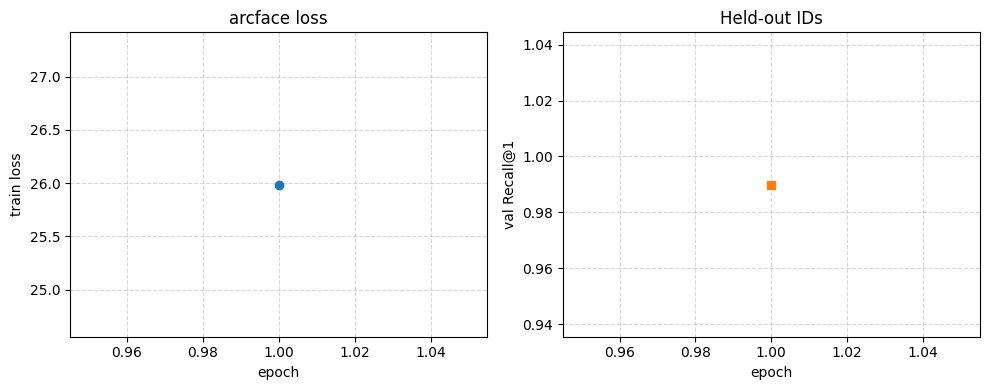

epoch 1/1: 100%|██████████| 405/405 [01:29<00:00,  4.52batch/s, loss=0.2014]


[epoch 01] train_loss=0.2014  val_recall@1=0.9846
  improved validation recall1, saved: checkpoints/dinov3_finetune_triplet.pt


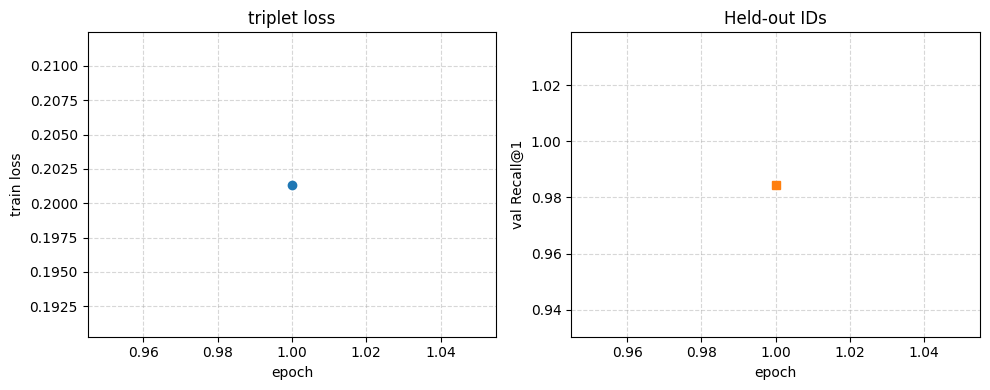

epoch 1/1: 100%|██████████| 405/405 [01:29<00:00,  4.54batch/s, loss=0.3377]


[epoch 01] train_loss=0.3377  val_recall@1=0.9834
  improved validation recall1, saved: checkpoints/dinov3_finetune_ntxent.pt


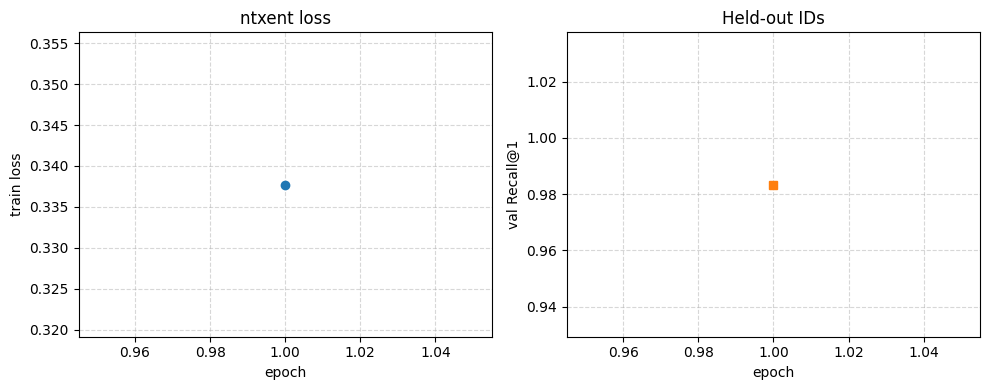

Best val Recall@1: 0.9899
Configuration:     arcface


In [ ]:
# Build full dataset first, then split into train / val by ID.
full_ds   = PRWQueryBoxDataset(TRAIN_CROPS_DIR, min_crops_per_id=2)
train_ids, val_ids = split_train_val_ids(
    full_ds.pids, val_frac=0.1, seed=42, min_crops_per_id=2
)
train_ds  = PRWQueryBoxDataset(TRAIN_CROPS_DIR, keep_ids=train_ids, min_crops_per_id=2)
val_ds    = PRWQueryBoxDataset(TRAIN_CROPS_DIR, keep_ids=val_ids,   min_crops_per_id=2)
print(f'train: {len(train_ds)} crops / {len(set(train_ds.labels))} ids')
print(f'val  : {len(val_ds)} crops / {len(set(val_ds.labels))} ids')

best_recall, best_cfg = 0, None

for RUN_CONFIG, cfg in REID_CONFIGS.items(): # e.g.: "arcface", {"encoder": "dinov3", "loss": "arcface"}
    # hyperparams
    LOSS_NAME   = cfg["loss"]
    EMBED_DIM   = cfg["embed_dim"]
    UNFREEZE_N  = 4
    EPOCHS      = 1
    TRAIN_BS    = 32
    M_PER_CLASS = 2
    LR_BACKBONE = 1e-4
    LR_HEAD     = 1e-3
    CHECKPOINT_PATH = f'checkpoints/dinov3_finetune_{RUN_CONFIG}.pt'

    ft_encoder = FineTunableDINOv3Encoder(
        embed_dim=EMBED_DIM, unfreeze_last_n_blocks=UNFREEZE_N, device=DEVICE,
    )

    history = train_encoder(
        ft_encoder, train_ds, val_ds,
        loss_name=LOSS_NAME, epochs=EPOCHS, batch_size=TRAIN_BS,
        m_per_class=M_PER_CLASS, lr_backbone=LR_BACKBONE, lr_head=LR_HEAD,
        checkpoint_path=CHECKPOINT_PATH, show_loss_plot=True
    )

    if history["best"] > best_recall:
        best_recall = history["best"]
        best_cfg = RUN_CONFIG

print(f'Best val Recall@1: {best_recall:.4f}')
print(f'Configuration:     {best_cfg}')

## 5. Gallery visual features

Five stages, each with disk caching (named by `RUN_CONFIG` to avoid cross-contamination):

2. **Visual features** — DINOv2 on each detected crop → `[n_det, 1024]` per frame

In [ ]:
def run_gallery_visual_features(gallery_dataset: PRWDataset, gallery_dets: list,
                                encoder: FineTunableDINOv3Encoder, cache_path: Path,
                                force: bool = False) -> list:
    """
    Extract DINOv2 CLS features for every detected person crop.
    Returns list of [n_det, D] L2-normalized float32 arrays; [0, D] for empty frames.
    """
    if cache_path.exists() and not force:
        print(f'Loading visual features from cache: {cache_path}')
        return list(np.load(str(cache_path), allow_pickle=True))

    D = encoder.feat_dim
    gallery_feats = []
    for i in tqdm(range(len(gallery_dataset)), desc='Visual features (gallery)', unit="frame"):
        dets = gallery_dets[i]
        if dets.shape[0] == 0:
            gallery_feats.append(np.zeros((0, D), dtype=np.float32))
            continue
        frame = Image.open(gallery_dataset.get_image_path(i)).convert('RGB')
        crops = _crop_persons(frame, dets)
        gallery_feats.append(encoder.encode_images(crops))   # [n_det, D]

    arr = np.empty(len(gallery_feats), dtype=object)
    for i, f in enumerate(gallery_feats):
        arr[i] = f
    np.save(str(cache_path), arr)
    print(f'Saved visual features: {cache_path}')
    return list(arr)

## 6. Query Processing

Query images are pre-cropped in `dataset/query_box/` — no detection step needed. We extract the same features as for gallery crops and fuse with the same `alpha`.

Note: `img_name` in query annotations is the **source frame** name (used by eval for exclusion), but `get_image_path` transparently returns the crop path.

In [ ]:
def run_query_features(query_dataset: PRWDataset, encoder: FineTunableDINOv3Encoder,
                       vis_cache: Path, force: bool = False) -> list:
    """
    Extract final L2-normalized features for all 2,057 query crops.
    Returns list of M [D] float32 vectors aligned with query_dataset.annotations.
    When captioner is None (Config A), returns visual-only features.
    Otherwise always fuses (even alpha=0) to keep dims consistent with gallery.
    """
    # ── Visual features ───────────────────────────────────────────────────────
    if vis_cache.exists() and not force:
        print(f'Loading query visual features from cache: {vis_cache}')
        vis_feats = np.load(str(vis_cache))                   # [M, D_v]
    else:
        paths     = [query_dataset.get_image_path(i) for i in range(len(query_dataset))]
        vis_list  = encoder.encode_crops_from_paths(paths, desc=f'{encoder.name} (queries)', disable_progress=False)
        vis_feats = np.stack(vis_list, axis=0)                # [M, D_v]
        np.save(str(vis_cache), vis_feats)
        print(f'Saved query visual features: {vis_cache}')

    return [vis_feats[i] for i in range(len(vis_feats))]

## 7. Evaluation

`eval_search_prw` evaluates person search performance:
- For each query, ranks all gallery detections by cosine similarity to the query feature
- Labels a detection as TP if IoU ≥ threshold with the ground-truth box for that person
- Computes per-query Average Precision, scaled by detection recall rate (penalizes missed detections)
- Returns **mAP** and **top-1 accuracy**

In [19]:
FORCE_RERUN_VISUAL_FEATURES = True
query_dataset   = build_query_dataset(DATASET_ROOT, split="test")
gallery_dataset = build_gallery_dataset(DATASET_ROOT, split="test")

for RUN_CONFIG, cfg in PERSONSEARCH_CONFIGS.items(): # e.g.: "A": {"detector": "yolo12", "threshold": 0.3, "encoder": "dinov3",  "loss": "arcface"}

    DETECTOR = cfg["detector"]
    DET_THRESH = cfg["threshold"]
    ENCODER = cfg["encoder"]
    EMBED_DIM = cfg["embed_dim"]
    LOSS = cfg["loss"]

    print(f"\n{'=' * 80}")
    print(f'Config {RUN_CONFIG} | detector={DETECTOR}, det_thresh={DET_THRESH}, encoder={ENCODER}, loss={LOSS}')
    print('=' * 80)

    # cache paths to avoid reruns
    DETS_CACHE = CACHE_DIR / f'gallery_dets_{DETECTOR}.npy' # we use detector for caching detections; so can be reusable
    VIS_CACHE  = CACHE_DIR / f'gallery_vis_{RUN_CONFIG}.npy' # by different configurations with same detector
    Q_VIS_CACHE  = CACHE_DIR / f'query_vis_{RUN_CONFIG}.npy' # visual features are computed on top detections; can't be shared by configurations with same visual encoder

    # load detector
    detector = build_detector(cfg)
    gallery_dets = run_gallery_detection(gallery_dataset, detector, DETS_CACHE)

    # load fine-tuned visual encoder
    CHECKPOINT_PATH = f'checkpoints/dinov3_finetune_{LOSS}.pt' # checkpoint are indexed by the loss
    ft_encoder = FineTunableDINOv3Encoder(embed_dim=EMBED_DIM,device=DEVICE)
    ft_encoder.load(CHECKPOINT_PATH)

    # compute visual features
    gallery_feats = run_gallery_visual_features(
        gallery_dataset, gallery_dets, ft_encoder, VIS_CACHE, force=FORCE_RERUN_VISUAL_FEATURES
    )

    query_box_feats = run_query_features(
        query_dataset, encoder=ft_encoder, vis_cache=Q_VIS_CACHE, force=FORCE_RERUN_VISUAL_FEATURES
    )

    # final evaluation
    results = eval_search_prw(
        gallery_dataset=gallery_dataset,
        query_dataset=query_dataset,
        gallery_dets=gallery_dets,
        gallery_feats=gallery_feats,
        query_box_feats=query_box_feats,
        det_thresh=DET_THRESH,
    )

    # save metrics in json
    out = {k: v.tolist() if isinstance(v, np.ndarray) else v
        for k, v in results.items() if k != 'results'}
    results_path = CACHE_DIR / f'results_{RUN_CONFIG}.json'
    with open(results_path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f'\nResults saved: {results_path}')

Loading gallery annotations:  32%|███▏      | 1954/6112 [00:00<00:00, 7874.40it/s]

Loading gallery annotations: 100%|██████████| 6112/6112 [00:00<00:00, 7821.41it/s]



Config A | detector=yolo12, det_thresh=0.3, encoder=dinov3, loss=arcface
Loading detections from cache: finetune_cache/gallery_dets_yolo12.npy


Visual features (gallery): 100%|██████████| 6112/6112 [02:56<00:00, 34.67frame/s]


Saved visual features → finetune_cache/gallery_vis_A.npy


...

Saved visual features → finetune_cache/gallery_vis_B.npy


Visual features (queries): 100%|██████████| 65/65 [00:11<00:00,  5.73batch/s]


Saved query visual features → finetune_cache/query_vis_B.npy
recall rate: 0.9375
search ranking:
  mAP = 57.18%
  top- 1 = 84.35%

Results saved: finetune_cache/results_B.json

Config C | detector=yolo12, det_thresh=0.3, encoder=dinov3, loss=ntxent
Loading detections from cache: finetune_cache/gallery_dets_yolo12.npy


Visual features (gallery):   4%|▍         | 248/6112 [00:08<03:10, 30.86frame/s]


KeyboardInterrupt: 

## 9. Qualitative Visualization

Display query crops alongside top-5 gallery retrievals. Green bounding box = correct match (IoU ≥ threshold); red = wrong.

In [ ]:
# Saved query visual features → finetune_cache/query_vis_A.npy
# recall rate: 0.9375
# search ranking:
#   mAP = 35.99%
#   top- 1 = 78.22%

# Results saved → finetune_cache/results_A.json

In [27]:
def visualize_query_results(results: dict, n_queries: int = 3, top_k: int = 5) -> None:
    img_root  = results['image_root']
    sample    = random.sample(results['results'], n_queries)
    ann_by_name = {a['img_name']: i for i, a in enumerate(query_dataset.annotations)}

    for entry in sample:
        fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 4))

        # Query crop: img_name = source frame; look up first matching annotation
        q_idx = ann_by_name.get(entry['query_img'], 0)
        axes[0].imshow(Image.open(query_dataset.get_image_path(q_idx)))
        axes[0].set_title(f'Query\n{entry["query_img"]}', fontsize=7)
        axes[0].axis('off')

        for k, hit in enumerate(entry['gallery'][:top_k]):
            frame = Image.open(os.path.join(img_root, hit['img']))
            axes[k + 1].imshow(frame)
            x1, y1, x2, y2 = hit['roi'][:4]
            color = 'lime' if hit['correct'] else 'red'
            axes[k + 1].add_patch(
                patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none',
                )
            )
            axes[k + 1].set_title(
                f'#{k+1} {"\u2713" if hit["correct"] else "\u2717"}\n{hit["score"]:.3f}',
                fontsize=8, color=color,
            )
            axes[k + 1].axis('off')

        plt.suptitle(f'Query source: {entry["query_img"]}', fontsize=9)
        plt.tight_layout()
        plt.show()

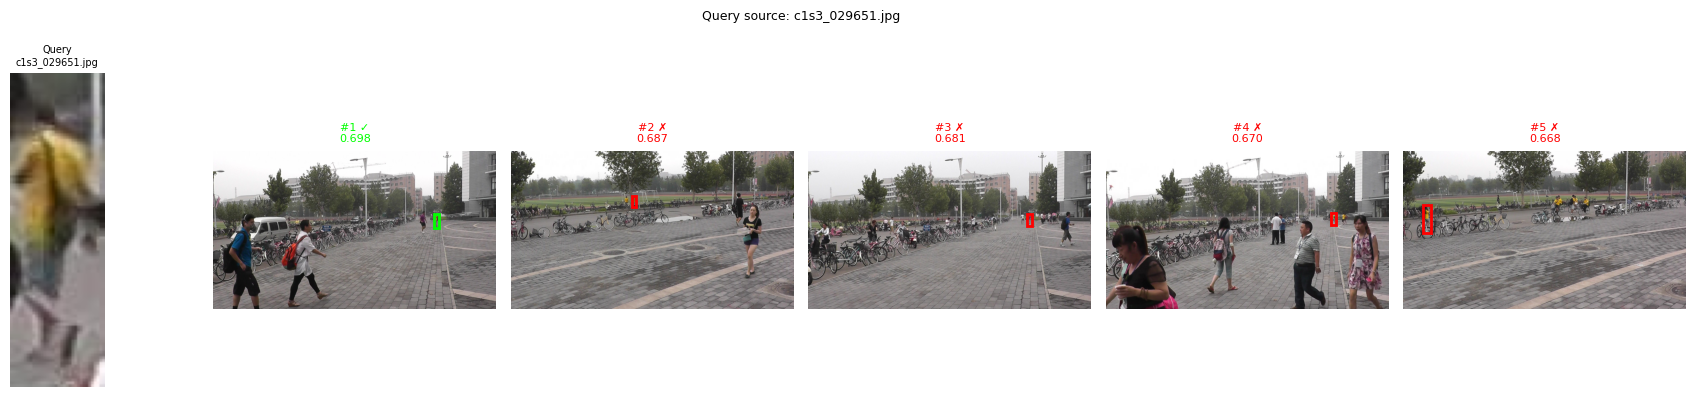

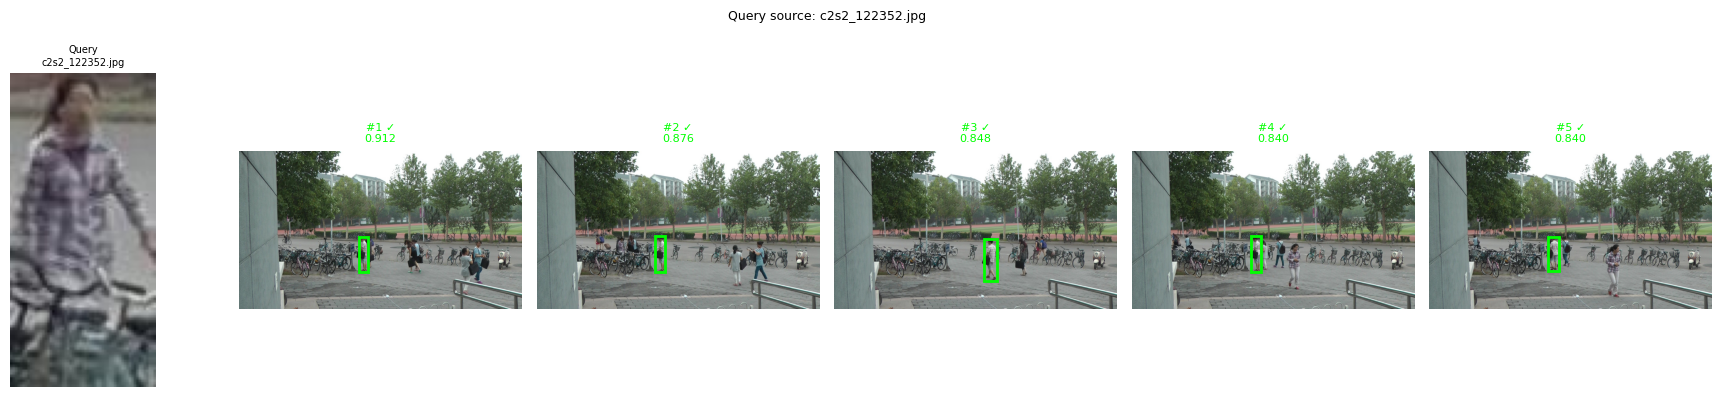

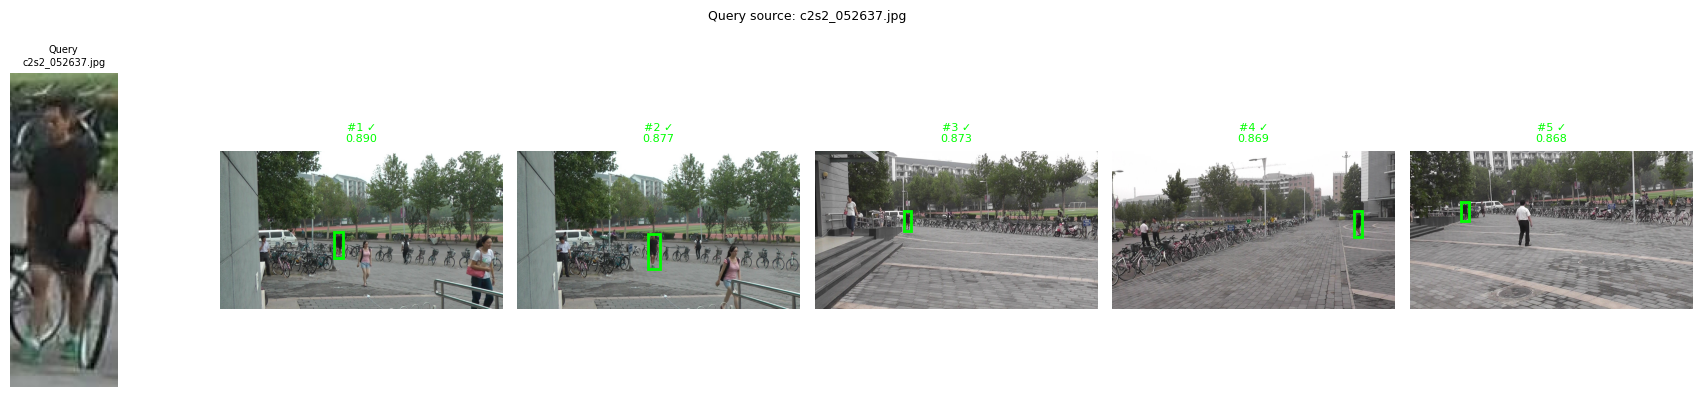

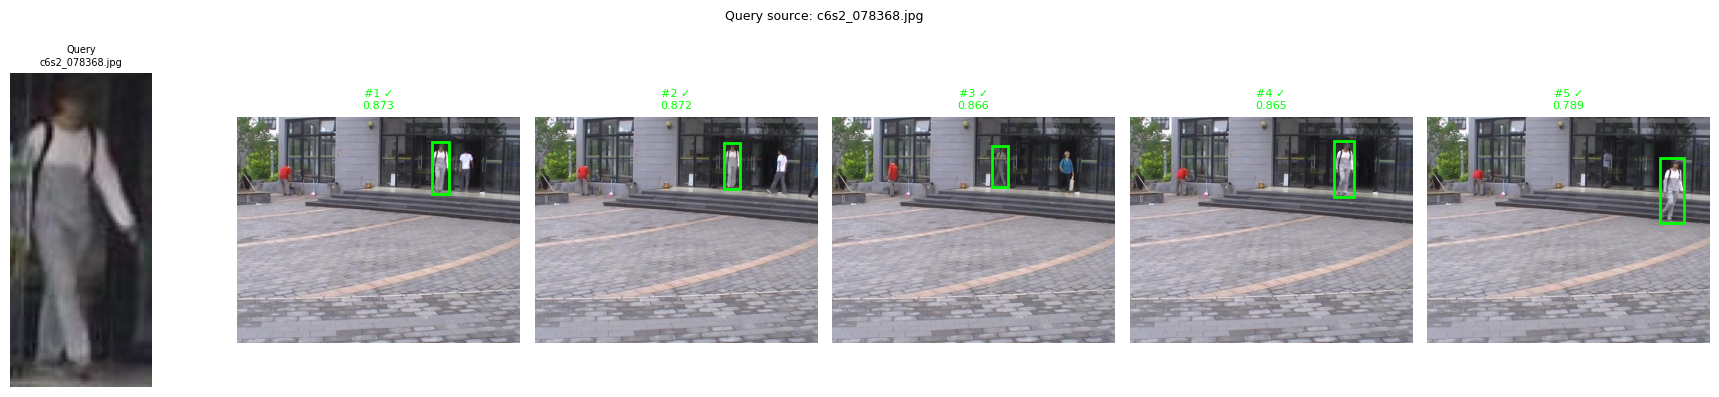

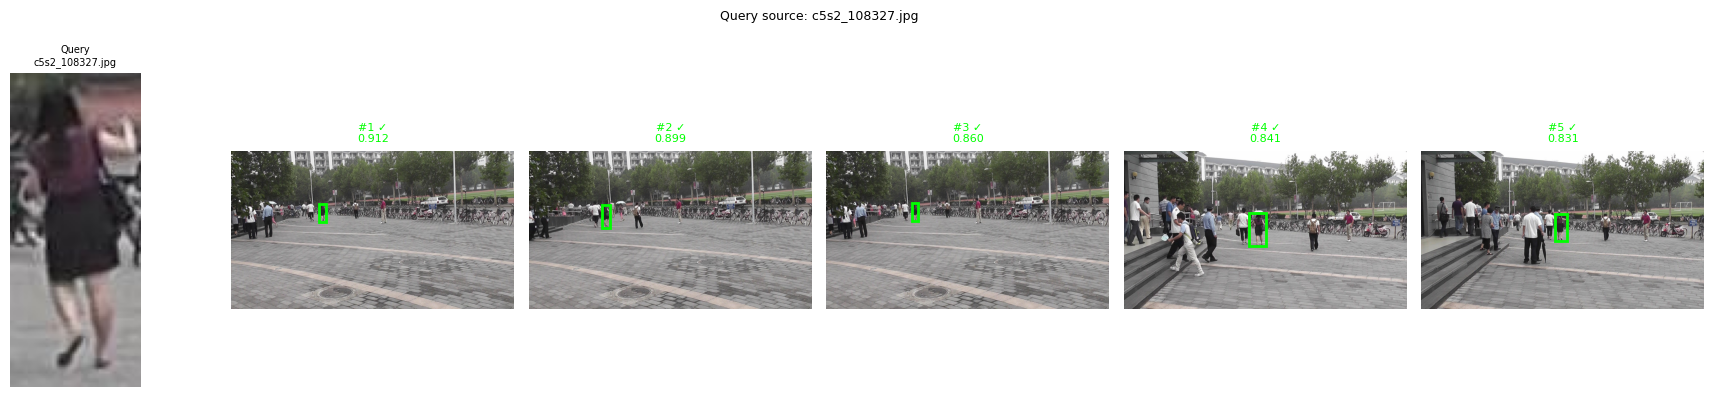

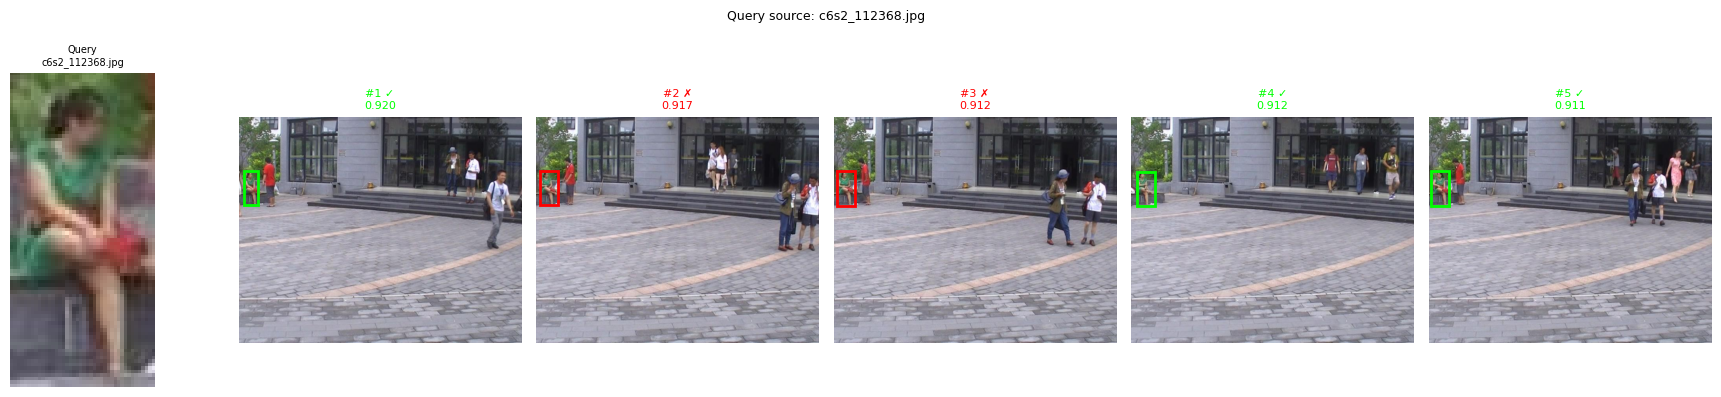

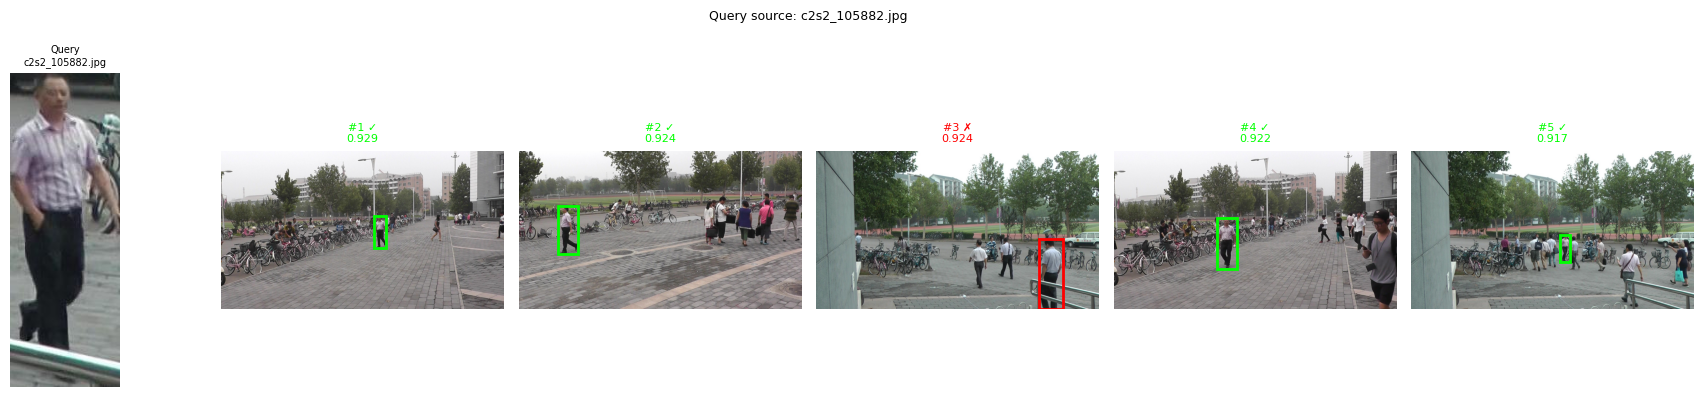

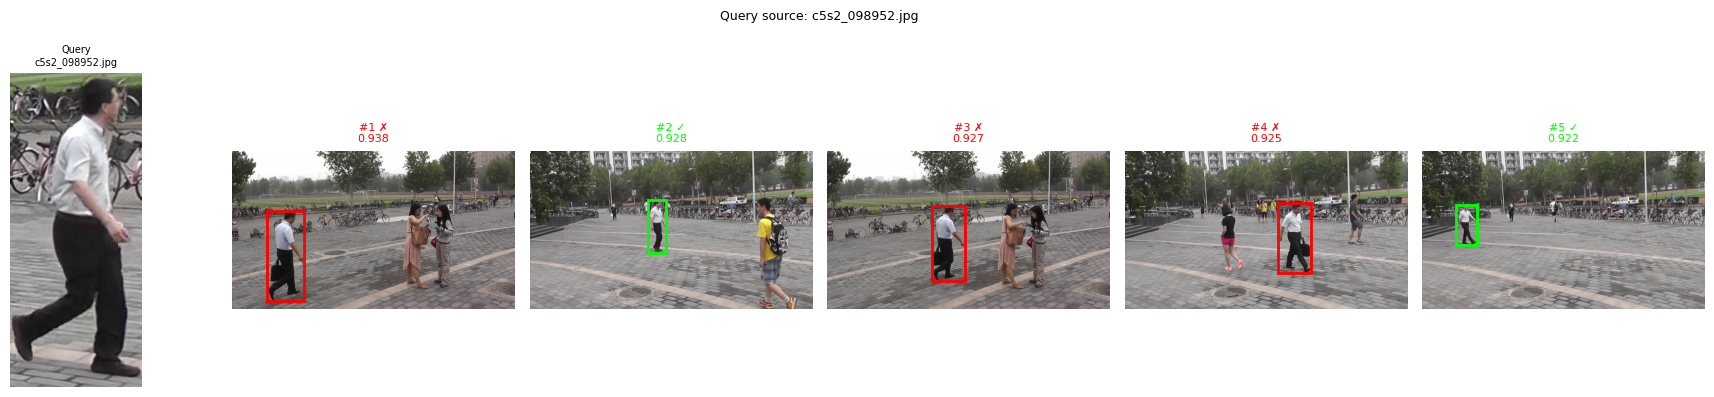

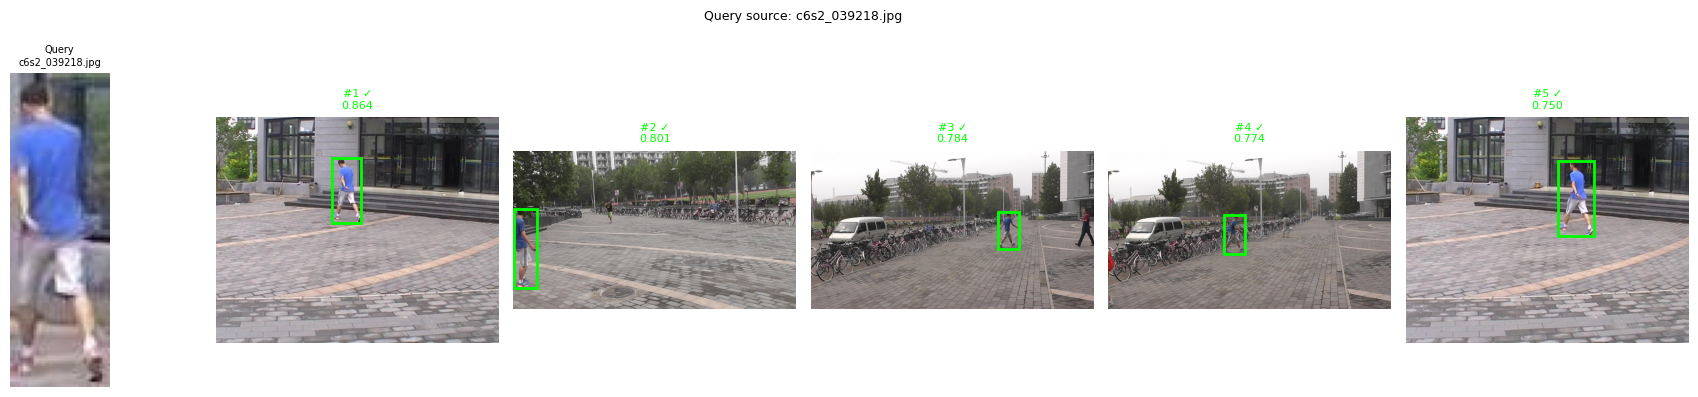

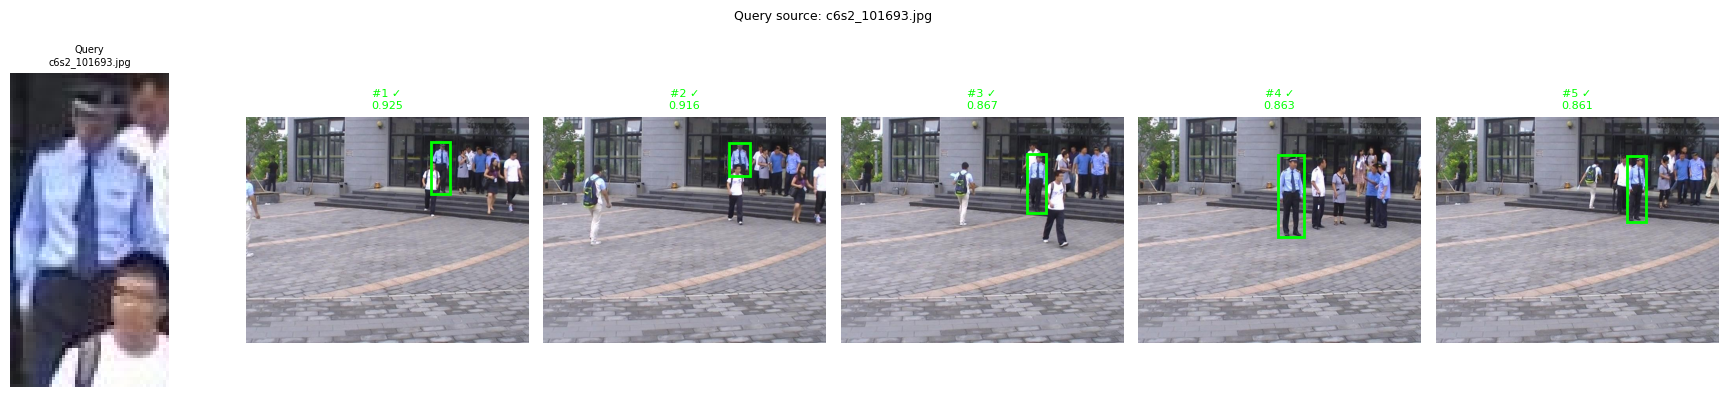

In [29]:
visualize_query_results(results, n_queries=10, top_k=5)